### Notebook for creating transect plots from LSTM data reconstruction

In [4]:
# Import libraries

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cmocean
from cmcrameri import cm as cmc
from scipy.spatial.distance import cdist
from scipy.interpolate import griddata
import os

In [5]:
# Paths and definitions

# Path to the NetCDF data file (has the date on the name)
data_path = "/home/nicolas/SACO/FRESH-CARE/Data_lstm_reconstruction/bering_6p25/product_stats/monthly/monthly_201202.nc"

# Variable-specific configurations (colormap and label)
variable_config = {
    "T_anom_pred": {
        "cmap": cmc.vik_r,
        "label": "Temperature Anomaly [ºC]"},
    "S_anom_pred": {
        "cmap": cmc.vik_r,
        "label": "Salinity Anomaly"},
     "T_recon": {
        "cmap": cmocean.cm.thermal,
        "label": "Temperature [ºC]"},
    "S_recon": {
        "cmap": cmocean.cm.haline,
        "label": "Salinity"},
    "T_glorys": {
        "cmap": cmocean.cm.thermal,
        "label": "Temperature [ºC]"},
    "S_glorys": {
        "cmap": cmocean.cm.haline,
        "label": "Salinity"},
    "T_anom_pred_mean": {
        "cmap": cmc.vik_r,
        "label": "Temperature Anomaly [ºC]"},
    "S_anom_pred_mean": {
        "cmap": cmc.vik_r,
        "label": "Salinity Anomaly"},
     "T_recon_mean": {
        "cmap": cmocean.cm.thermal,
        "label": "Temperature [ºC]"},
    "S_recon_mean": {
        "cmap": cmocean.cm.haline,
        "label": "Salinity"},
    "T_glorys_mean": {
        "cmap": cmocean.cm.thermal,
        "label": "Temperature [ºC]"},
    "S_glorys_mean": {
        "cmap": cmocean.cm.haline,
        "label": "Salinity"}
}


# Gateway Transect Definitions :[lon1,lat1], [lon2,lat2]
gateways = {
    "Bering": [[-169.7, 66.0333], [-168.0996, 65.685]],
    "Bering_southern": [[-169.75, 65.3], [-168.1, 65.15]],
    "Fram": [[-17.5, 79], [11, 79]],
    "Barents": [[20, 70], [20, 78]],
    "Davis": [[-61, 66], [-54, 66]],
    "Alaska - Novaya Zemlya": [[-135, 70], [68.5, 77.3]]
}

# CONFIGURATION!!!! Edit these variables to change the plot
variable = "S_anom_pred_mean"  # Options: T_recon, S_recon, T_anom_pred, S_anom_pred
                      #          T_glorys, S_glorys...
gateway = "Bering"     # Options: Bering, Bering_southern, Fram, Barents, Davis, Alaska - Novaya Zemlya
plot_type = "contour"  # Options: "scatter", "contour"


In [6]:
# Loading dataset

ds = xr.open_dataset(data_path)
print("Dataset loaded successfully!")
if 'time' in ds.dims:
    time_stamp = ds['time'].values[0]
    print(f"Time dimension found. Using time: {time_stamp}")

ds

Dataset loaded successfully!
Time dimension found. Using time: 2012-02-15T00:00:00.000000000


<xarray.Dataset> Size: 21MB
Dimensions:                (time: 1, depth: 102, y_ease: 32, x_ease: 56)
Coordinates:
  * time                   (time) datetime64[ns] 8B 2012-02-15
  * depth                  (depth) float64 816B 0.0 5.0 10.0 ... 5.4e+03 5.5e+03
  * y_ease                 (y_ease) float64 256B 2.553e+06 ... 2.747e+06
  * x_ease                 (x_ease) float64 448B -6.719e+05 ... -3.281e+05
Data variables: (12/34)
    T_anom_pred_mean       (time, depth, y_ease, x_ease) float32 731kB ...
    T_anom_pred_std        (time, depth, y_ease, x_ease) float32 731kB ...
    S_anom_pred_mean       (time, depth, y_ease, x_ease) float32 731kB ...
    S_anom_pred_std        (time, depth, y_ease, x_ease) float32 731kB ...
    T_recon_mean           (time, depth, y_ease, x_ease) float32 731kB ...
    T_recon_std            (time, depth, y_ease, x_ease) float32 731kB ...
    ...                     ...
    ocean_mask             (y_ease, x_ease) uint8 2kB ...
    elevation              (y_ease, x_ease) float64 14kB ...
    latitude               (y_ease, x_ease) float64 14kB ...
    longitude              (y_ease, x_ease) float64 14kB ...
    ease_grid_mapping      int64 8B ...
    n_samples              (time, depth, y_ease, x_ease) int32 731kB ...
Attributes: (12/36)
    title:                       Temporal statistics (monthly) — February 201...
    summary:                     Arctic 4-D ocean reconstruction (ease_6.25km...
    Conventions:                 CF-1.8, ACDD-1.3
    source:                      LSTM with Monte-Carlo Dropout, trained on Ar...
    history:                     2026-05-29T08:18:11Z — compute_reconst_stats...
    creation_date:               2026-05-19T12:36:32Z
    ...                          ...
    period_end:                  2012-02-29
    partial:                     false
    time_coverage_start:         2012-02-01
    time_coverage_end:           2012-02-28
    source_files_first:          TS_currents_lstm_20120201.nc
    source_files_last:           TS_currents_lstm_20120228.nc

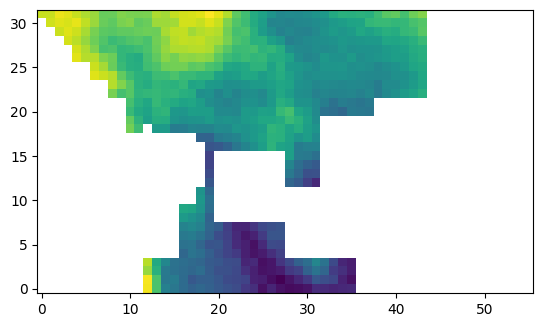

In [7]:
plt.imshow(ds[f'{variable}'].isel(time=0, depth=0), origin='lower')

In [8]:
# Plotting function for single gateway section

def plot_single_gateway_section(
    ds,
    gateways,
    gateway_name,
    title=None,
    variable="T_recon",
    cmap=None,
    cbar_label=None,
    vmin=None,
    vmax=None,
    vcenter=None,
    max_depth=None,
    plot_type='scatter', 
    savefig=False,
    date_str=None,
    save_path='.',
    dpi=300
):
    """
    Plot a vertical section (transect) of a selected variable across a defined gateway.
    Overlays real bathymetry from the 'elevation' variable.
    
    Parameters:
    plot_type: 'scatter' for scattered points, 'contour' for interpolated contours
    vcenter: if not None, remap `cmap` so this value (typically 0) sits at the
        colormap's mid color, keeping zero on white for asymmetric vmin/vmax.
    """

    # Build asymmetric colormap + norm if vcenter is set and vmin<vcenter<vmax
    norm = None
    if (vcenter is not None and vmin is not None and vmax is not None
            and vmin < vcenter < vmax and cmap is not None):
        import matplotlib as _mpl
        _cf = (vcenter - vmin) / (vmax - vmin)
        _n = 256
        _n_neg = max(1, min(_n - 1, round(_n * _cf)))
        _base = cmap if callable(cmap) else plt.get_cmap(cmap)
        _cmap_colors = np.vstack([
            _base(np.linspace(0.0, 0.5, _n_neg)),
            _base(np.linspace(0.5, 1.0, _n - _n_neg)),
        ])
        cmap = _mpl.colors.LinearSegmentedColormap.from_list(
            f"{_base.name}_asym", _cmap_colors)

        class _AsymNorm(_mpl.colors.Normalize):
            def __init__(self, vmin, vcenter, vmax, cf):
                self._vc, self._cf = vcenter, cf
                super().__init__(vmin, vmax)
            def __call__(self, value, clip=None):
                v = np.ma.asarray(value)
                result = np.interp(v.filled(np.nan),
                                   [self.vmin, self._vc, self.vmax],
                                   [0, self._cf, 1])
                return np.ma.array(result, mask=np.ma.getmaskarray(v))
            def inverse(self, value):
                return np.interp(value, [0, self._cf, 1],
                                 [self.vmin, self._vc, self.vmax])
        norm = _AsymNorm(vmin, vcenter, vmax, _cf)

    # Get gateway points
    point1, point2 = gateways[gateway_name]
    lon1, lat1 = point1
    lon2, lat2 = point2
    
    # Use existing lat/lon coordinates from dataset
    lat_grid = ds['latitude'].values  # (350, 350)
    lon_grid = ds['longitude'].values  # (350, 350)
    elevation = ds['elevation'].values  # (350, 350)

    # Create line between the two points
    n_points = 50  # Number of points along the line
    line_lons = np.linspace(lon1, lon2, n_points)
    line_lats = np.linspace(lat1, lat2, n_points)

    # Find nearest grid points for each point along the line
    grid_points = np.column_stack([lon_grid.ravel(), lat_grid.ravel()])
    line_points = np.column_stack([line_lons, line_lats])

    # Find nearest neighbors
    distances = cdist(line_points, grid_points)
    nearest_indices = np.argmin(distances, axis=1)

    # Convert 1D indices back to 2D grid indices
    y_indices, x_indices = np.unravel_index(nearest_indices, lat_grid.shape)

    # Get coordinates and bathymetry for the section
    section_lons = lon_grid[y_indices, x_indices]
    section_lats = lat_grid[y_indices, x_indices]
    section_bathy = elevation[y_indices, x_indices]

    # Determine which coordinate varies more (for x-axis)
    lon_range = np.max(section_lons) - np.min(section_lons)
    lat_range = np.max(section_lats) - np.min(section_lats)
    
    if lon_range > lat_range:
        x_coords = section_lons
        xlabel = "Longitude [°]"
    else:
        x_coords = section_lats
        xlabel = "Latitude [°]"
    
    # Extract bathymetry for section
    h_bathy = section_bathy.copy()
    x_bathy = x_coords.copy()
    
    # Ensure bathymetry is negative down
    if np.nanmax(h_bathy) > 0:
        h_bathy = -np.abs(h_bathy)
    
    # Extract variable data
    var_data = ds[variable]
    if 'time' in var_data.dims:
        var_data = var_data.isel(time=0)
    
    # Extract profiles for each section point
    x_section = []
    z_section = []
    var_section = []
    
    depth_coords = ds['depth'].values

    for i, (y_idx, x_idx) in enumerate(zip(y_indices, x_indices)):
        profile = var_data.values[:, y_idx, x_idx]
        valid_profile = ~np.isnan(profile)
        
        if np.any(valid_profile):
            n_valid = np.sum(valid_profile)
            x_section.extend([x_coords[i]] * n_valid)
            z_section.extend(-depth_coords[valid_profile])
            var_section.extend(profile[valid_profile])
    
    x_section = np.array(x_section) 
    z_section = np.array(z_section)
    var_section = np.array(var_section)

    if len(x_section) == 0:
        print("No valid data found in section!")
        return

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))

    if max_depth is not None:
        max_depth = -abs(max_depth)  # Ensure it's negative down
    
    # Calculate dynamic depth limit based on deepest data + 300m
    if max_depth is None:
        deepest_data = np.nanmin(z_section)
        max_depth = deepest_data - 300
    
    # Plot bathymetry (background)
    h_bathy_clipped = np.maximum(h_bathy, max_depth)
    ax.fill_between(x_bathy, h_bathy_clipped, max_depth, color="darkgray", alpha=0.7, zorder=1)
    
    # Plot variable data
    if plot_type == 'scatter':
        # Original scatter plot
        _kw = dict(c=var_section, s=8, cmap=cmap, alpha=1.0, zorder=10)
        if norm is not None:
            _kw['norm'] = norm
        else:
            _kw['vmin'], _kw['vmax'] = vmin, vmax
        pc = ax.scatter(x_section, z_section, **_kw)
    
    elif plot_type == 'contour':
        # Interpolated contour plot
        
        # Create regular grid for interpolation
        x_min, x_max = np.nanmin(x_coords), np.nanmax(x_coords)
        z_min, z_max = max_depth, 0
        
        # Grid resolution
        nx, nz = 100, 50
        xi = np.linspace(x_min, x_max, nx)
        zi = np.linspace(z_min, z_max, nz)
        Xi, Zi = np.meshgrid(xi, zi)
        
        # Interpolate data onto regular grid
        points = np.column_stack([x_section, z_section])
        try:
            Vi = griddata(points, var_section, (Xi, Zi), method='linear')
            
            # Create bathymetry mask - interpolate bathymetry to same grid
            bathy_interp = np.interp(xi, x_bathy, h_bathy)
            
            # Mask where grid is above bathymetry
            for i in range(nx):
                mask_depth = bathy_interp[i]
                Vi[:, i] = np.where(Zi[:, i] < mask_depth, np.nan, Vi[:, i])
            
            # Plot filled contours
            levels = 20
            if norm is not None:
                _lvls = np.linspace(vmin, vmax, levels)
                pc = ax.contourf(Xi, Zi, Vi, levels=_lvls, cmap=cmap, norm=norm,
                               extend='both', zorder=-1)
            else:
                pc = ax.contourf(Xi, Zi, Vi, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax, 
                               extend='both', zorder=-1)
            
        except Exception as e:
            print(f"Interpolation failed: {e}. Falling back to scatter plot.")
            _kw = dict(c=var_section, s=8, cmap=cmap, alpha=1.0, zorder=-1)
            if norm is not None:
                _kw['norm'] = norm
            else:
                _kw['vmin'], _kw['vmax'] = vmin, vmax
            pc = ax.scatter(x_section, z_section, **_kw)
    
    else:
        raise ValueError("plot_type must be 'scatter' or 'contour'")
    
    # Set limits
    ax.set_xlim(np.nanmin(x_coords), np.nanmax(x_coords))
    ax.set_ylim(max_depth, 0)
    
    # Labels and title
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Depth [m]")
    if title is not None:
        ax.set_title(title)
    else:
        ax.set_title(f"{gateway_name} Transect – {variable}")
    
    # Colorbar
    cbar = fig.colorbar(pc, ax=ax, label=cbar_label, shrink=0.8, extend='both')
    # Clean tick set: ~6 nicely-rounded ticks; include vcenter if defined
    from matplotlib.ticker import MaxNLocator, FormatStrFormatter
    if vmin is not None and vmax is not None:
        ticks = MaxNLocator(nbins=6, steps=[1, 2, 2.5, 5, 10]).tick_values(vmin, vmax)
        ticks = ticks[(ticks >= vmin) & (ticks <= vmax)]
        if vcenter is not None and not np.any(np.isclose(ticks, vcenter)):
            ticks = np.sort(np.append(ticks, vcenter))
        cbar.set_ticks(ticks)
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    if savefig:
        filename = (f"{date_str+'_' if date_str is not None else ''}"
                    f"{gateway_name}_{variable}"
                    f"_{plot_type}_section.png")
        os.makedirs(save_path, exist_ok=True)
        fig.savefig(f"{save_path}/{filename}", dpi=dpi, bbox_inches='tight')
        print(f"Figure saved as {save_path}/{filename}")
    
    plt.show()


Interpolation failed: QH6013 qhull input error: input is less than 3-dimensional since all points have the same x coordinate -168.1

While executing:  | qhull d Qz Qbb Q12 Qt Qc
Options selected for Qhull 2020.2.r 2020/08/31:
  run-id 711109111  delaunay  Qz-infinity-point  Qbbound-last  Q12-allow-wide
  Qtriangulate  Qcoplanar-keep  _pre-merge  _zero-centrum  Qinterior-keep
  Pgood  _max-width 15  Error-roundoff 2.3e-13  _one-merge 1.6e-12
  Visible-distance 4.7e-13  U-max-coplanar 4.7e-13  Width-outside 9.3e-13
  _wide-facet 2.8e-12  _maxoutside 1.9e-12
. Falling back to scatter plot.


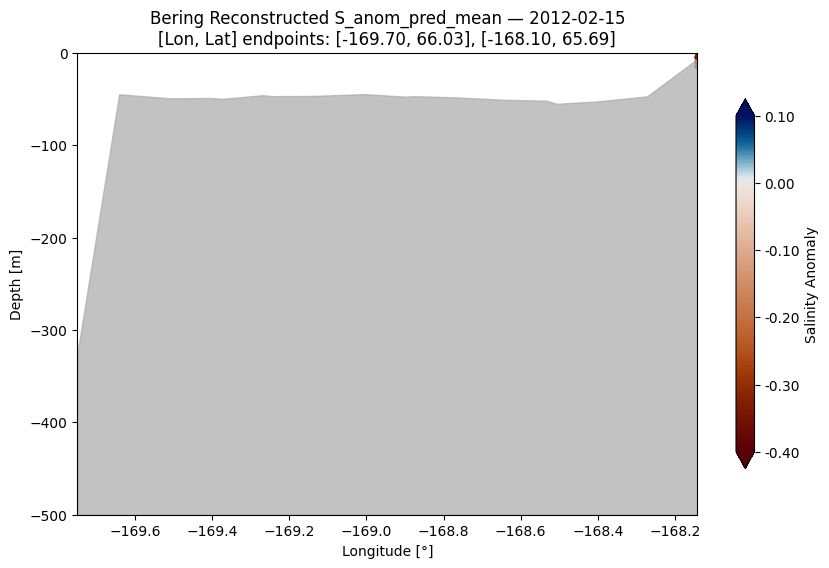

In [9]:
# Plotting

p1, p2 = gateways[gateway]
var_name = variable.replace('_recon', '')
date_str = np.datetime_as_string(time_stamp, unit='D')
title = (f"{gateway} Reconstructed {var_name} — {date_str}\n"
         f"[Lon, Lat] endpoints: [{p1[0]:.2f}, {p1[1]:.2f}], [{p2[0]:.2f}, {p2[1]:.2f}]")

plot_single_gateway_section(
    ds,
    gateways=gateways,
    gateway_name=gateway,
    title = title,
    variable=variable,
    cmap=variable_config[variable]["cmap"],
    cbar_label=variable_config[variable]["label"],
    plot_type=plot_type,
    vmin=-0.4, vmax=0.1,
    vcenter=0,
    max_depth=500,
    savefig=False,
    date_str=date_str,
    save_path='/home/nicolas/SACO/FRESH-CARE/Data_lstm_reconstruction/arctic_25km/plots/transects',
    dpi=350)